In [ ]:
# ============================================================
# 셀 1: 라이브러리 설치
# ============================================================
!pip install mediapipe scikit-learn scipy joblib matplotlib
!apt-get install -y ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [ ]:
# ============================================================
# 셀 2: 구글 드라이브 마운트
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

J_DIR = "/content/drive/MyDrive/jz_gesture/j_videos"
Z_DIR = "/content/drive/MyDrive/jz_gesture/z_videos"

j_files = [f for f in os.listdir(J_DIR) if f.endswith('.MOV') or f.endswith('.mov')]
z_files = [f for f in os.listdir(Z_DIR) if f.endswith('.MOV') or f.endswith('.mov')]

print(f"J 영상: {len(j_files)}개 → {j_files}")
print(f"Z 영상: {len(z_files)}개 → {z_files}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
J 영상: 6개 → ['IMG_3236.MOV', 'IMG_8186.MOV', 'IMG_3237.MOV', 'IMG_8188.MOV', 'IMG_3638.MOV', 'IMG_3639.MOV']
Z 영상: 9개 → ['IMG_8187.MOV', 'IMG_8189.MOV', 'IMG_3238.MOV', 'IMG_3637.MOV', 'IMG_3640.MOV', 'IMG_3641.MOV', 'IMG_3791.MOV', 'IMG_3792.MOV', 'IMG_3793.MOV']


In [ ]:
# ============================================================
# 셀 3: MOV → MP4 변환 (드라이브 저장, 이미 변환된 건 스킵)
# ============================================================
import subprocess
import os

CONVERTED_J_DIR = "/content/drive/MyDrive/jz_gesture/converted/J"
CONVERTED_Z_DIR = "/content/drive/MyDrive/jz_gesture/converted/Z"

os.makedirs(CONVERTED_J_DIR, exist_ok=True)
os.makedirs(CONVERTED_Z_DIR, exist_ok=True)

def convert_mov_to_mp4(src_dir, file_list, out_dir):
    converted = []
    for f in file_list:
        dst = os.path.join(out_dir, f.replace('.MOV', '.mp4').replace('.mov', '.mp4'))
        if os.path.exists(dst):
            print(f"  스킵 (이미 변환됨): {os.path.basename(dst)}")
            converted.append(dst)
            continue
        src = os.path.join(src_dir, f)
        subprocess.run(
            ['ffmpeg', '-i', src, '-vcodec', 'libx264', '-acodec', 'aac', dst, '-y'],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        print(f"  변환 완료: {f} → {os.path.basename(dst)}")
        converted.append(dst)
    return converted

print("J 영상 변환 중...")
j_converted = convert_mov_to_mp4(J_DIR, j_files, CONVERTED_J_DIR)

print("\nZ 영상 변환 중...")
z_converted = convert_mov_to_mp4(Z_DIR, z_files, CONVERTED_Z_DIR)

print("\n완료!")

J 영상 변환 중...
  스킵 (이미 변환됨): IMG_3236.mp4
  스킵 (이미 변환됨): IMG_8186.mp4
  스킵 (이미 변환됨): IMG_3237.mp4
  스킵 (이미 변환됨): IMG_8188.mp4
  스킵 (이미 변환됨): IMG_3638.mp4
  스킵 (이미 변환됨): IMG_3639.mp4

Z 영상 변환 중...
  스킵 (이미 변환됨): IMG_8187.mp4
  스킵 (이미 변환됨): IMG_8189.mp4
  스킵 (이미 변환됨): IMG_3238.mp4
  스킵 (이미 변환됨): IMG_3637.mp4
  스킵 (이미 변환됨): IMG_3640.mp4
  스킵 (이미 변환됨): IMG_3641.mp4
  스킵 (이미 변환됨): IMG_3791.mp4
  스킵 (이미 변환됨): IMG_3792.mp4
  스킵 (이미 변환됨): IMG_3793.mp4

완료!


In [ ]:
# ============================================================
# 셀 4: 궤적 추출 (Tasks API)
# ============================================================
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import os

if not os.path.exists("hand_landmarker.task"):
    import urllib.request
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
        "hand_landmarker.task"
    )
    print("다운로드 완료!")
else:
    print("이미 있음, 스킵!")

def is_fist(landmarks):
    tips = [8, 12, 16, 20]
    pips = [6, 10, 14, 18]
    mcps = [5,  9, 13, 17]
    for tip, pip, mcp in zip(tips, pips, mcps):
        tip_dist = ((landmarks[tip].x - landmarks[mcp].x)**2 + (landmarks[tip].y - landmarks[mcp].y)**2)**0.5
        pip_dist = ((landmarks[pip].x - landmarks[mcp].x)**2 + (landmarks[pip].y - landmarks[mcp].y)**2)**0.5
        if tip_dist > pip_dist * 1.0:
            return False
    return True

def extract_samples(video_paths, finger_idx, label):
    all_samples = []
    base_opts  = mp_python.BaseOptions(model_asset_path="hand_landmarker.task")
    options    = mp_vision.HandLandmarkerOptions(base_options=base_opts, num_hands=1)
    landmarker = mp_vision.HandLandmarker.create_from_options(options)

    for path in video_paths:
        cap = cv2.VideoCapture(path)
        current_track = []
        prev_fist = False

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            h, w     = frame.shape[:2]
            rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result   = landmarker.detect(mp_image)

            if result.hand_landmarks:
                lms  = result.hand_landmarks[0]
                fist = is_fist(lms)
                if fist:
                    if not prev_fist and len(current_track) >= 15:
                        all_samples.append(current_track.copy())
                    current_track = []
                    prev_fist = True
                else:
                    tip = lms[finger_idx]
                    current_track.append((int(tip.x * w), int(tip.y * h)))
                    prev_fist = False
            else:
                prev_fist = False

        if len(current_track) >= 15:
            all_samples.append(current_track)
        cap.release()
        print(f"  {os.path.basename(path)}: 누적 {len(all_samples)}개")

    landmarker.close()
    print(f"{label} 총 샘플: {len(all_samples)}개\n")
    return all_samples

print("J 궤적 추출 중...")
J_samples = extract_samples(j_converted, finger_idx=20, label="J")

print("Z 궤적 추출 중...")
Z_samples = extract_samples(z_converted, finger_idx=8, label="Z")

이미 있음, 스킵!
J 궤적 추출 중...
  IMG_3236.mp4: 누적 24개
  IMG_8186.mp4: 누적 37개
  IMG_3237.mp4: 누적 67개
  IMG_8188.mp4: 누적 92개
  IMG_3638.mp4: 누적 122개
  IMG_3639.mp4: 누적 145개
J 총 샘플: 145개

Z 궤적 추출 중...
  IMG_8187.mp4: 누적 7개
  IMG_8189.mp4: 누적 11개
  IMG_3238.mp4: 누적 26개
  IMG_3637.mp4: 누적 49개
  IMG_3640.mp4: 누적 77개
  IMG_3641.mp4: 누적 100개
  IMG_3791.mp4: 누적 107개
  IMG_3792.mp4: 누적 110개
  IMG_3793.mp4: 누적 115개
Z 총 샘플: 115개



In [ ]:
# 셀 4.5: J 샘플 후처리 필터링
def is_valid_trajectory(pts, min_len=20, min_displacement=30):
    if len(pts) < min_len:
        return False
    arr = np.array(pts)
    # 전체 이동 범위가 너무 작으면 제거
    bbox_h = arr[:, 1].max() - arr[:, 1].min()
    bbox_w = arr[:, 0].max() - arr[:, 0].min()
    if bbox_h < min_displacement and bbox_w < min_displacement:
        return False
    return True

J_samples_filtered = [s for s in J_samples if is_valid_trajectory(s)]
Z_samples_filtered = [s for s in Z_samples if is_valid_trajectory(s)]

print(f"J: {len(J_samples)} → {len(J_samples_filtered)}개")
print(f"Z: {len(Z_samples)} → {len(Z_samples_filtered)}개")

# 이후 셀에서 J_samples, Z_samples 대신 이걸 사용
J_samples = J_samples_filtered
Z_samples = Z_samples_filtered

J: 145 → 139개
Z: 115 → 105개


/tmp/ipykernel_784/248369104.py:25: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_784/248369104.py:25: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_784/248369104.py:25: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_784/248369104.py:25: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_784/248369104.py:25: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_784/248369104.py:25: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_784/248369104.py:25: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

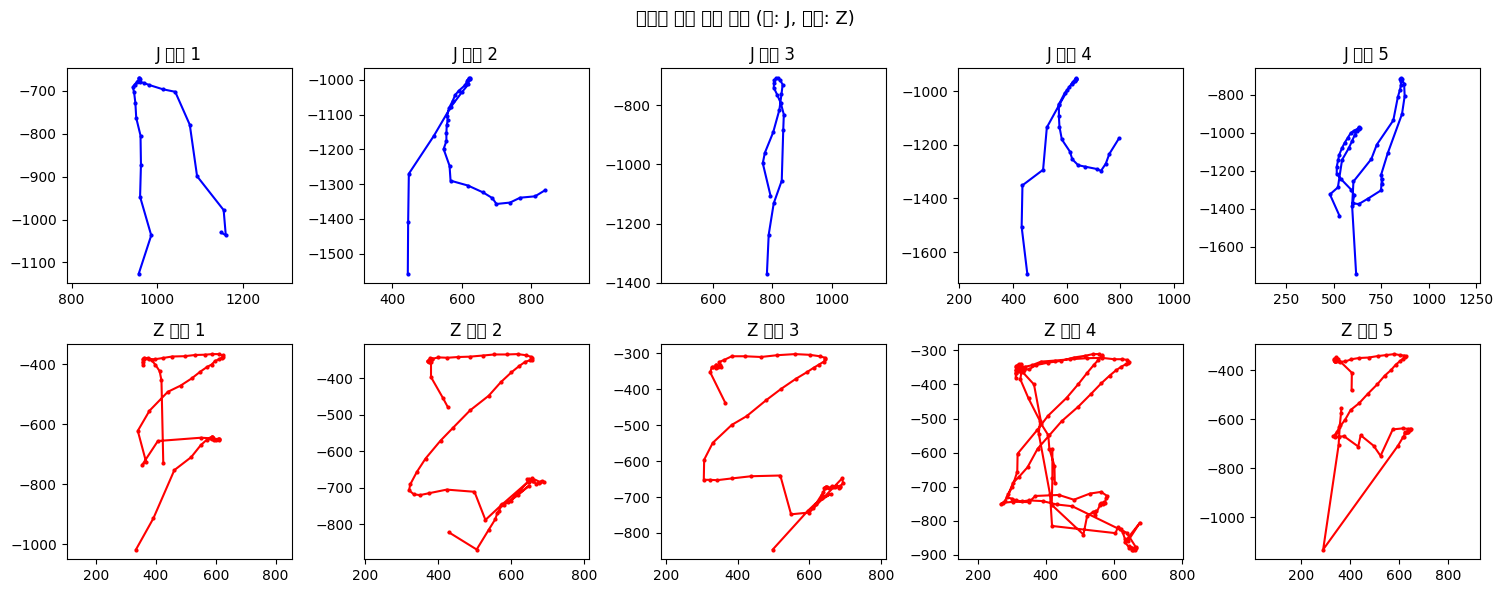

In [ ]:
# ============================================================
# 셀 5: 궤적 시각화 (잘 추출됐는지 확인)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes[0]):
    if i < len(J_samples):
        pts = np.array(J_samples[i])
        ax.plot(pts[:, 0], -pts[:, 1], 'b-o', markersize=2)
        ax.set_title(f"J 샘플 {i+1}")
        ax.axis('equal')
    ax.axis('off') if i >= len(J_samples) else None

for i, ax in enumerate(axes[1]):
    if i < len(Z_samples):
        pts = np.array(Z_samples[i])
        ax.plot(pts[:, 0], -pts[:, 1], 'r-o', markersize=2)
        ax.set_title(f"Z 샘플 {i+1}")
        ax.axis('equal')
    ax.axis('off') if i >= len(Z_samples) else None

plt.suptitle("추출된 궤적 샘플 확인 (위: J, 아래: Z)", fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_784/110431021.py:15: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_784/110431021.py:15: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


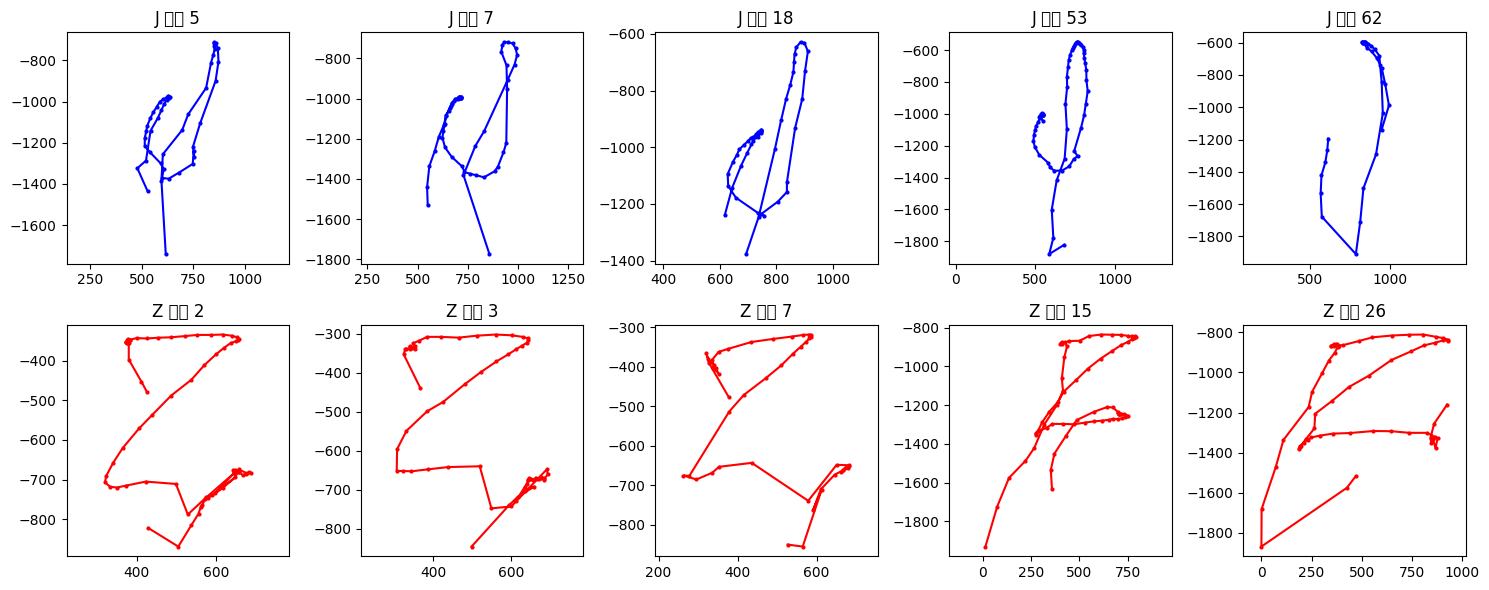

In [ ]:
good_J = [4, 6, 17, 52, 61]
good_Z = [1, 2, 6, 14, 25]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes[0]):
    pts = np.array(J_samples[good_J[i]])
    ax.plot(pts[:, 0], -pts[:, 1], 'b-o', markersize=2)
    ax.set_title(f"J  {good_J[i]+1}")
    ax.axis('equal')
for i, ax in enumerate(axes[1]):
    pts = np.array(Z_samples[good_Z[i]])
    ax.plot(pts[:, 0], -pts[:, 1], 'r-o', markersize=2)
    ax.set_title(f"Z 샘플 {good_Z[i]+1}")
    ax.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 셀 6: 전처리
# ============================================================
from scipy.interpolate import interp1d

FIXED_LEN = 30

def preprocess(track_points):
    pts = np.array(track_points, dtype=float)
    if len(pts) < 2:
        return None
    t     = np.linspace(0, 1, len(pts))
    t_new = np.linspace(0, 1, FIXED_LEN)
    resampled = np.stack([
        interp1d(t, pts[:, 0])(t_new),
        interp1d(t, pts[:, 1])(t_new),
    ], axis=1)
    resampled -= resampled.min(axis=0)
    max_val = resampled.max()
    if max_val > 0:
        resampled /= max_val
    return resampled.flatten()

J_feats = [f for f in [preprocess(s) for s in J_samples] if f is not None]
Z_feats = [f for f in [preprocess(s) for s in Z_samples] if f is not None]

print(f"전처리 완료 - J: {len(J_feats)}개, Z: {len(Z_feats)}개")

전처리 완료 - J: 139개, Z: 105개


In [ ]:
# ============================================================
# 셀 7: 샘플 수별 정확도 비교
# ============================================================
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

def run_experiment(n_samples, J_feats, Z_feats, random_state=42):
    X = np.array(J_feats + Z_feats)
    y = np.array([0]*len(J_feats) + [1]*len(Z_feats))

    X_train_pool, X_test, y_train_pool, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    n = min(n_samples, len(np.where(y_train_pool==0)[0]), len(np.where(y_train_pool==1)[0]))
    train_J = np.where(y_train_pool == 0)[0][:n]
    train_Z = np.where(y_train_pool == 1)[0][:n]
    X_train = X_train_pool[np.concatenate([train_J, train_Z])]
    y_train = y_train_pool[np.concatenate([train_J, train_Z])]

    scaler = StandardScaler()
    model  = SVC(kernel='rbf', probability=True)
    model.fit(scaler.fit_transform(X_train), y_train)
    acc = accuracy_score(y_test, model.predict(scaler.transform(X_test)))

    return acc, model, scaler

results = []
best_model, best_scaler = None, None

for n in [50, 75, 100, 125, 150]:
    acc, model, scaler = run_experiment(n, J_feats, Z_feats)
    results.append({"샘플 수 (클래스당)": n, "정확도": f"{acc*100:.1f}%", "정확도_수치": acc})
    if n == 150:
        best_model, best_scaler = model, scaler
    print(f"샘플 {n}개: {acc*100:.1f}%")

print("\n=== 비교 결과 ===")
print(pd.DataFrame(results)[["샘플 수 (클래스당)", "정확도"]].to_string(index=False))

샘플 50개: 89.8%
샘플 75개: 93.9%
샘플 100개: 95.9%
샘플 125개: 95.9%
샘플 150개: 95.9%

=== 비교 결과 ===
 샘플 수 (클래스당)   정확도
          50 89.8%
          75 93.9%
         100 95.9%
         125 95.9%
         150 95.9%


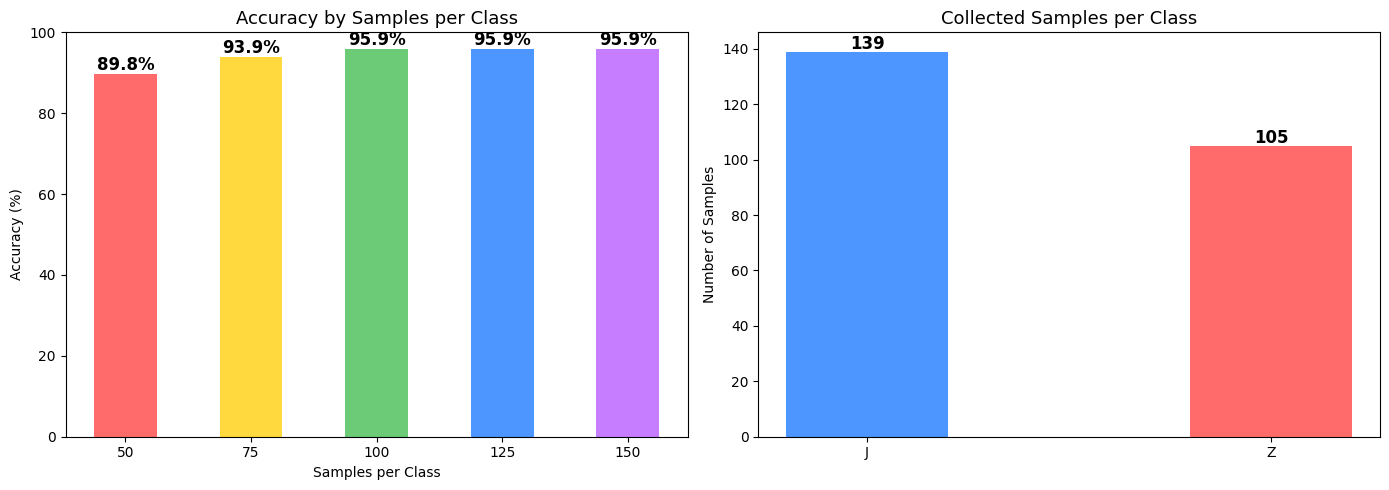

Graph saved to Drive!


In [ ]:
# ============================================================
# 셀 8: 비교 그래프
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

accs = [r["정확도_수치"]*100 for r in results]
bars = axes[0].bar(["50", "75", "100", "125", "150"], accs,
                    color=["#ff6b6b", "#ffd93d", "#6bcb77", "#4d96ff", "#c77dff"], width=0.5)
axes[0].set_ylim(0, 100)
axes[0].set_title("Accuracy by Samples per Class", fontsize=13)
axes[0].set_xlabel("Samples per Class")
axes[0].set_ylabel("Accuracy (%)")
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v+1,
                 f"{v:.1f}%", ha='center', fontsize=12, fontweight='bold')

axes[1].bar(["J", "Z"], [len(J_feats), len(Z_feats)],
            color=["#4d96ff", "#ff6b6b"], width=0.4)
axes[1].set_title("Collected Samples per Class", fontsize=13)
axes[1].set_ylabel("Number of Samples")
for i, v in enumerate([len(J_feats), len(Z_feats)]):
    axes[1].text(i, v+1, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/jz_gesture/comparison.png", dpi=150)
plt.show()
print("Graph saved to Drive!")

In [ ]:
# ============================================================
# 셀 9: 모델 저장 (드라이브 + 로컬 다운로드)
# ============================================================
import joblib
from google.colab import files

os.makedirs("/content/drive/MyDrive/jz_gesture/models", exist_ok=True)

# 드라이브에 저장
joblib.dump(best_model,  "/content/drive/MyDrive/jz_gesture/models/gesture_svm.pkl")
joblib.dump(best_scaler, "/content/drive/MyDrive/jz_gesture/models/gesture_scaler.pkl")

# 로컬 다운로드
joblib.dump(best_model,  "/content/gesture_svm.pkl")
joblib.dump(best_scaler, "/content/gesture_scaler.pkl")
files.download("/content/gesture_svm.pkl")
files.download("/content/gesture_scaler.pkl")

print("완료! FingerType/models/ 폴더에 넣어줘")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

완료! FingerType/models/ 폴더에 넣어줘


              precision    recall  f1-score   support

           J       1.00      0.93      0.96        28
           Z       0.91      1.00      0.95        21

    accuracy                           0.96        49
   macro avg       0.96      0.96      0.96        49
weighted avg       0.96      0.96      0.96        49



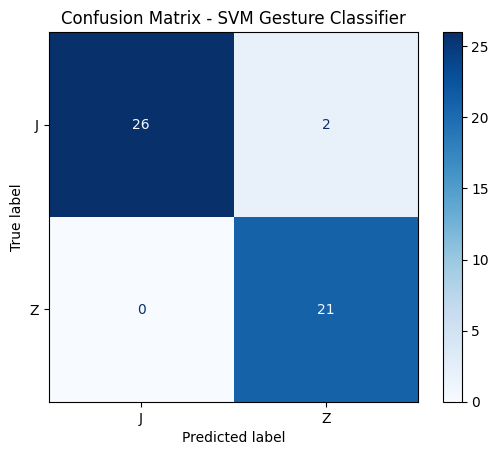

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(J_feats + Z_feats)
y = np.array([0]*len(J_feats) + [1]*len(Z_feats))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
model = SVC(kernel='rbf', probability=True)
model.fit(scaler.fit_transform(X_train), y_train)
y_pred = model.predict(scaler.transform(X_test))

print(classification_report(y_test, y_pred, target_names=["J", "Z"]))

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["J", "Z"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM Gesture Classifier")
plt.savefig("/content/drive/MyDrive/jz_gesture/confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    SVC(kernel='rbf', probability=True),
    scaler.fit_transform(X), y,
    cv=5, scoring='accuracy'
)
print(f"5-Fold CV: {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

5-Fold CV: 96.3% ± 3.0%
